In [2]:
import os
import pandas as pd
import geopandas as gpd
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt

In [3]:
graph_path = "../data/raw/christchurch_drive.graphml"
pois_path = "../data/raw/christchurch_pois.geojson"

G = ox.load_graphml(graph_path)
pois = gpd.read_file(pois_path)

print(len(pois))
pois.head()

134


,element,id,branch,brand,brand:wikidata,brand:wikipedia,check_date,name,opening_hours,phone,...,payment:visa_debit,short_name,payment:eftpos,indoor,construction,facebook,area,building:part,type,geometry
0,node,469313826,Barrington,FreshChoice,Q22271877,en:FreshChoice,2025-01-13,FreshChoice,Mo-Su 07:00-22:00,+64 3 943 9222,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (172.6206 -43.55576)
1,node,1225250003,NaN,NaN,NaN,NaN,NaT,Forensic Community Team,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (172.58933 -43.54868)
2,node,1649789483,Hornby,PAK'nSAVE,Q7125339,en:Pak'nSave,NaT,PAK'nSAVE,Mo-Su 07:00-23:00,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (172.52318 -43.54279)
3,node,1722643297,Fendalton,FreshChoice,Q22271877,en:FreshChoice,NaT,FreshChoice,Mo-Su 07:00-21:00,+64 3 351 9075,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (172.59028 -43.50951)
4,node,2161706945,Fendalton,New World,Q7012488,en:New World (supermarket),NaT,New World,Mo-Su 07:30-21:00,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (172.58838 -43.51793)


In [4]:
pois = pois[pois.geometry.type == "Point"].copy()

keep_cols = [col for col in ["amenity", "shop", "name", "geometry"] if col in pois.columns]
pois = pois[keep_cols].copy()

def classify_service(row):
    if row.get("amenity") in ["hospital", "clinic"]:
        return "healthcare"
    if row.get("shop") == "supermarket":
        return "supermarket"
    return "other"

pois["service_type"] = pois.apply(classify_service, axis=1)
pois = pois[pois["service_type"].isin(["healthcare", "supermarket"])].copy()

pois["x"] = pois.geometry.x
pois["y"] = pois.geometry.y

pois["nearest_node"] = ox.distance.nearest_nodes(
    G,
    X=pois["x"],
    Y=pois["y"]
)

pois["service_type"].value_counts()

service_type
supermarket    38
healthcare     25
Name: count, dtype: int64

In [5]:
healthcare_pois = pois[pois["service_type"] == "healthcare"].copy()
supermarket_pois = pois[pois["service_type"] == "supermarket"].copy()

print("Healthcare:", len(healthcare_pois))
print("Supermarkets:", len(supermarket_pois))

Healthcare: 25
Supermarkets: 38


In [6]:
def nearest_distance_to_targets(graph, source_node, target_nodes, weight="length"):
    distances = []
    for target in target_nodes:
        try:
            d = nx.shortest_path_length(graph, source=source_node, target=target, weight=weight)
            distances.append(d)
        except nx.NetworkXNoPath:
            continue
    return min(distances) if distances else None

In [7]:
healthcare_nodes = healthcare_pois["nearest_node"].tolist()
supermarket_nodes = supermarket_pois["nearest_node"].tolist()

pois["dist_to_healthcare_m"] = pois["nearest_node"].apply(
    lambda node: nearest_distance_to_targets(G, node, healthcare_nodes)
)

pois["dist_to_supermarket_m"] = pois["nearest_node"].apply(
    lambda node: nearest_distance_to_targets(G, node, supermarket_nodes)
)

pois[["name", "service_type", "dist_to_healthcare_m", "dist_to_supermarket_m"]].head()

pois[["dist_to_healthcare_m", "dist_to_supermarket_m"]].describe()

,dist_to_healthcare_m,dist_to_supermarket_m
count,63.000000,63.000000
mean,859.847397,411.179347
std,1319.648405,671.711612
min,0.000000,0.000000
25%,0.000000,0.000000
50%,428.342348,0.000000
75%,1379.955955,596.460345
max,7748.667458,2235.964596


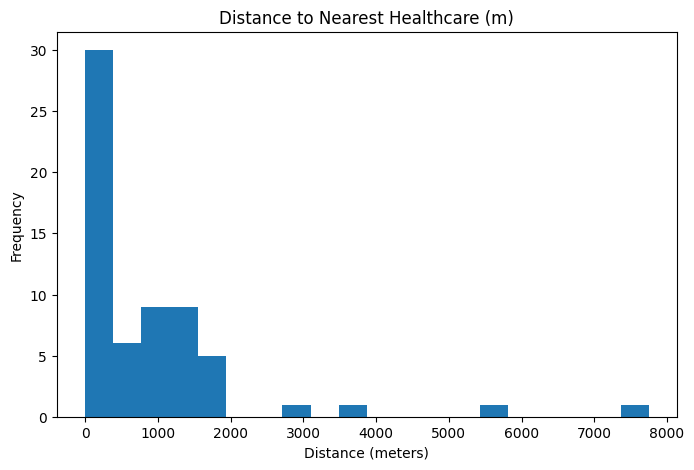

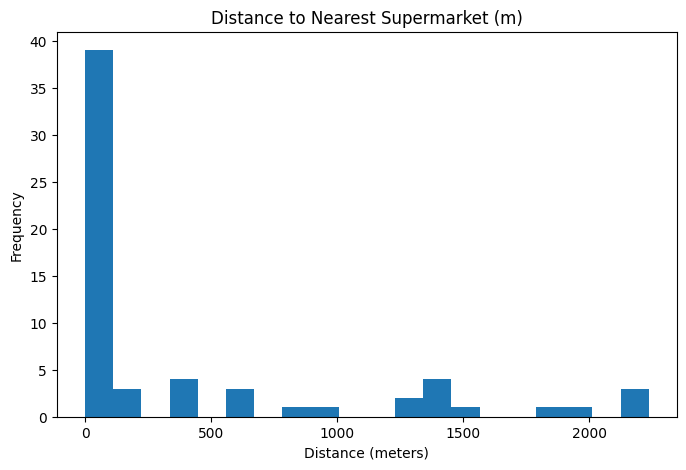

In [8]:
pois["dist_to_healthcare_m"].plot(kind="hist", bins=20, figsize=(8, 5), title="Distance to Nearest Healthcare (m)")
plt.xlabel("Distance (meters)")
plt.show()

pois["dist_to_supermarket_m"].plot(kind="hist", bins=20, figsize=(8, 5), title="Distance to Nearest Supermarket (m)")
plt.xlabel("Distance (meters)")
plt.show()

In [9]:
os.makedirs("../outputs", exist_ok=True)
pois.to_file("../outputs/pois_accessibility.geojson", driver="GeoJSON")
pois.drop(columns="geometry").to_csv("../outputs/pois_accessibility.csv", index=False)